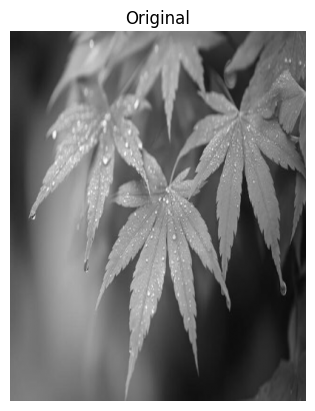

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

img = cv2.imread('img.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (400, 500))
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()

In [2]:
def add_gaussian_noise(image, sigma=25):
    noise = np.random.normal(0, sigma, image.shape)
    return np.clip(image + noise, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, amount=0.1):
    output = image.copy()
    coords = np.random.random(image.shape[:2]) < amount / 2
    pepper_coords = coords & (np.random.random(image.shape[:2]) < 0.5)
    salt_coords = coords & ~pepper_coords
    output[pepper_coords] = 0
    output[salt_coords] = 255
    return output

def add_uniform_noise(image, scale=30):
    noise = np.random.uniform(-scale, scale, image.shape)
    return np.clip(image + noise, 0, 255).astype(np.uint8)

def add_rayleigh_noise(image, scale=20):
    noise = np.random.rayleigh(scale, image.shape)
    return np.clip(image + noise, 0, 255).astype(np.uint8)

def add_exponential_noise(image, lam=0.05):
    noise = np.random.exponential(lam, image.shape) * 100
    return np.clip(image + noise, 0, 255).astype(np.uint8)

In [3]:
def geometric_mean(img, size=3):
    log_img = np.log(img.astype(float) + 1)
    kernel = np.ones((size, size)) / (size * size)
    filtered = ndimage.convolve(log_img, kernel)
    return np.exp(filtered).astype(np.uint8)

def contraharmonic_mean(img, size=3, Q=1.5):
    num = ndimage.uniform_filter(img ** (Q + 1), size)
    den = ndimage.uniform_filter(img ** Q, size) + 1e-10
    return np.clip(num / den, 0, 255).astype(np.uint8)

def alpha_trimmed(img, size=3, d=2):
    return ndimage.rank_filter(img, size**2//2 - d//2, size).astype(np.uint8)

# Task 1: Noise types

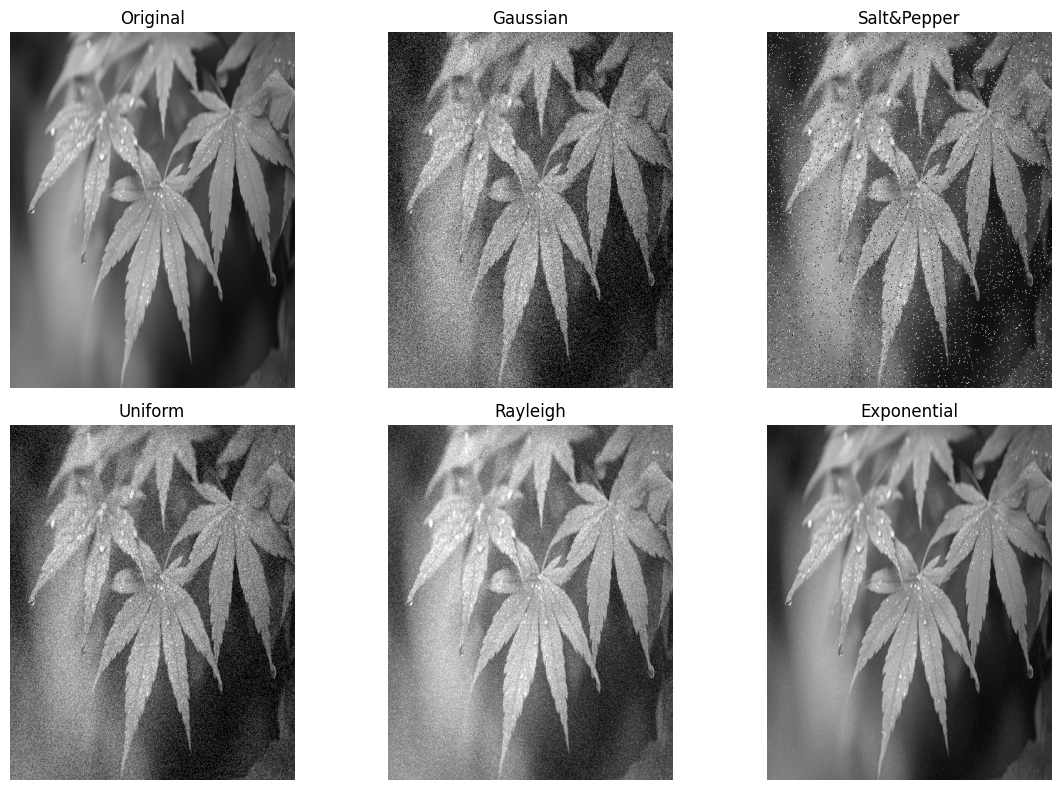

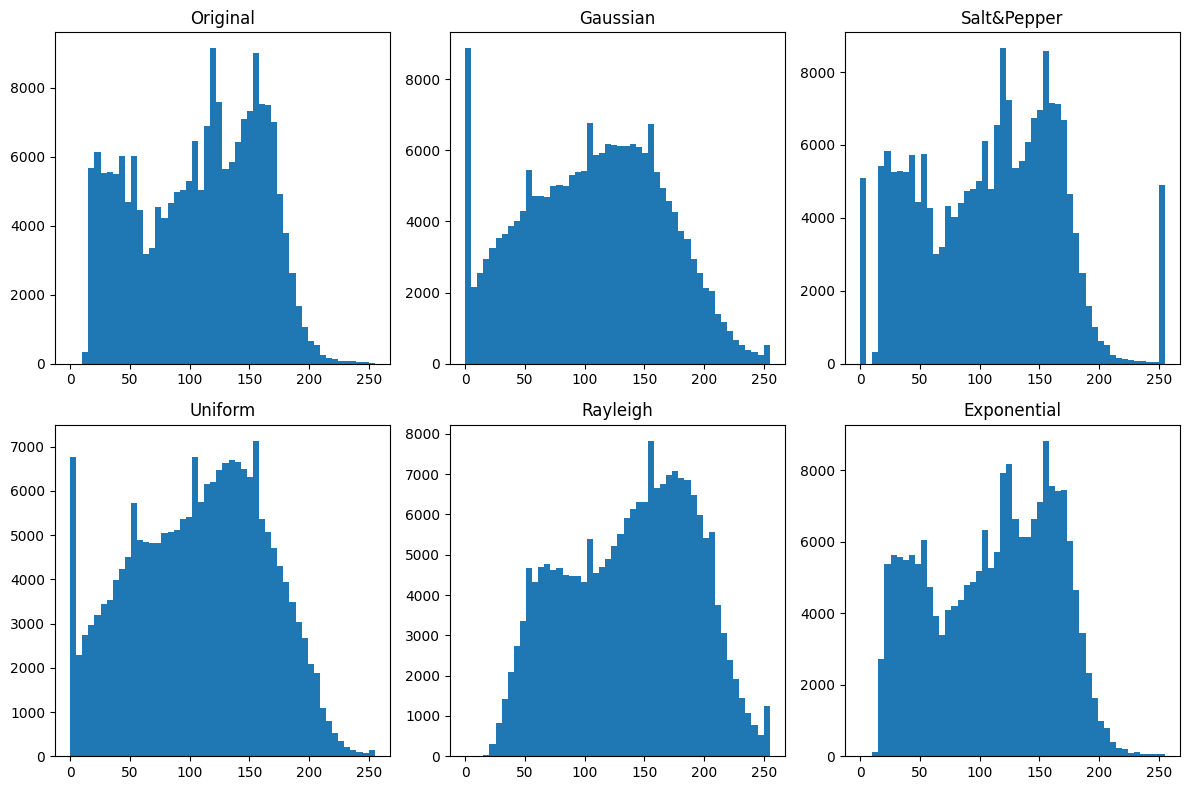

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

noisy_images = {
    'Original': img,
    'Gaussian': add_gaussian_noise(img, 30),
    'Salt&Pepper': add_salt_pepper_noise(img, 0.1),
    'Uniform': add_uniform_noise(img, 40),
    'Rayleigh': add_rayleigh_noise(img, 25),
    'Exponential': add_exponential_noise(img, 0.04)
}

for idx, (name, noisy) in enumerate(noisy_images.items()):
    axes[idx//3, idx%3].imshow(noisy, cmap='gray')
    axes[idx//3, idx%3].set_title(name)
    axes[idx//3, idx%3].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, (name, noisy) in enumerate(noisy_images.items()):
    axes[idx//3, idx%3].hist(noisy.flatten(), bins=50, range=(0, 255))
    axes[idx//3, idx%3].set_title(name)
plt.tight_layout()
plt.show()

# Task 2: Filters on Gaussian noise

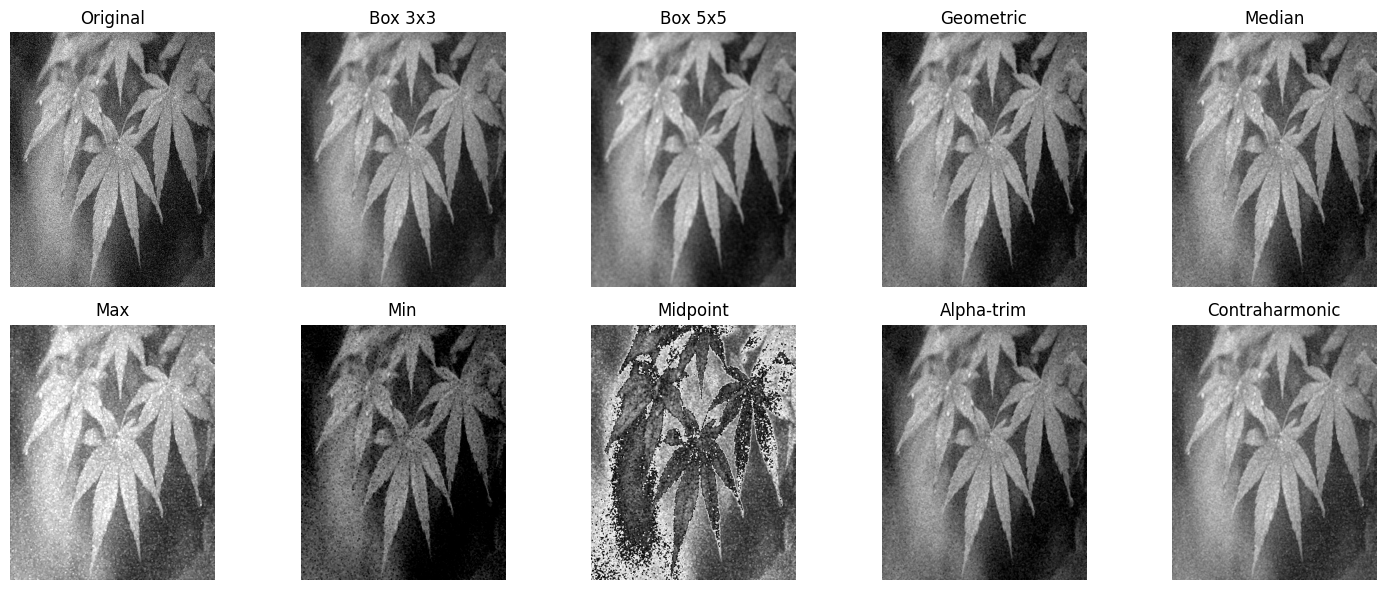

In [5]:
noisy_g = add_gaussian_noise(img, 30)

results = {
    'Original': noisy_g,
    'Box 3x3': cv2.blur(noisy_g, (3, 3)),
    'Box 5x5': cv2.blur(noisy_g, (5, 5)),
    'Geometric': geometric_mean(noisy_g),
    'Median': ndimage.median_filter(noisy_g, 3),
    'Max': ndimage.maximum_filter(noisy_g, 3),
    'Min': ndimage.minimum_filter(noisy_g, 3),
    'Midpoint': (ndimage.maximum_filter(noisy_g, 3) + ndimage.minimum_filter(noisy_g, 3)) / 2,
    'Alpha-trim': alpha_trimmed(noisy_g, 3, 2),
    'Contraharmonic': contraharmonic_mean(noisy_g, 3, 1.5)
}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, (name, res) in enumerate(results.items()):
    axes[idx//5, idx%5].imshow(res, cmap='gray')
    axes[idx//5, idx%5].set_title(name)
    axes[idx//5, idx%5].axis('off')
plt.tight_layout()
plt.show()

# Task 3: Salt & Pepper and mixed noise

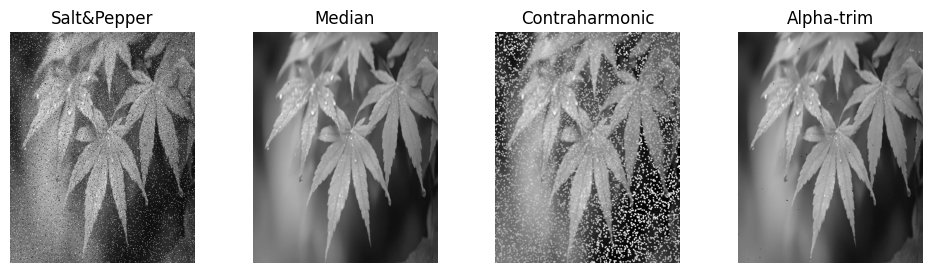

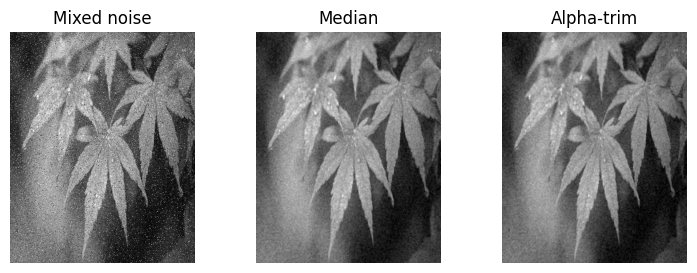

In [6]:
noisy_sp = add_salt_pepper_noise(img, 0.15)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(noisy_sp, cmap='gray')
axes[0].set_title('Salt&Pepper')
axes[0].axis('off')
axes[1].imshow(ndimage.median_filter(noisy_sp, 3), cmap='gray')
axes[1].set_title('Median')
axes[1].axis('off')
axes[2].imshow(contraharmonic_mean(noisy_sp, 3, 1.5), cmap='gray')
axes[2].set_title('Contraharmonic')
axes[2].axis('off')
axes[3].imshow(alpha_trimmed(noisy_sp, 3, 2), cmap='gray')
axes[3].set_title('Alpha-trim')
axes[3].axis('off')
plt.show()

mixed = add_gaussian_noise(add_salt_pepper_noise(img, 0.08), 20)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(mixed, cmap='gray')
axes[0].set_title('Mixed noise')
axes[0].axis('off')
axes[1].imshow(ndimage.median_filter(mixed, 3), cmap='gray')
axes[1].set_title('Median')
axes[1].axis('off')
axes[2].imshow(alpha_trimmed(mixed, 3, 2), cmap='gray')
axes[2].set_title('Alpha-trim')
axes[2].axis('off')
plt.show()